In [2]:
!pip install -q pandas numpy matplotlib scikit-learn river psutil

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 79.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [3]:
import os
import time
import zipfile
import random
import warnings
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from river import tree

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

ELEC_ZIP_PATH = "/content/archive (6).zip"
GAS_ZIP_PATH = "/content/archive (7).zip"

ELEC_EXTRACT_DIR = "/content/extracted_elec2_hd"
GAS_EXTRACT_DIR = "/content/extracted_gas_hd"

ELEC_RESULTS_DIR = "/content/elec2_hd_results"
GAS_RESULTS_DIR = "/content/gas_hd_results"
COMBINED_RESULTS_DIR = "/content/final_combined_results"

ELEC_ROLLING_WINDOW = 500
ELEC_PRINT_EVERY = 2000
ELEC_MAX_ROWS = None

GAS_ROLLING_WINDOW = 300
GAS_PRINT_EVERY = 1000
GAS_MAX_ROWS = None

# Create folders
os.makedirs(ELEC_EXTRACT_DIR, exist_ok=True)
os.makedirs(GAS_EXTRACT_DIR, exist_ok=True)
os.makedirs(ELEC_RESULTS_DIR, exist_ok=True)
os.makedirs(GAS_RESULTS_DIR, exist_ok=True)
os.makedirs(COMBINED_RESULTS_DIR, exist_ok=True)

print("Setup complete.")

Setup complete.


In [4]:
def extract_zip(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_to)
    print(f"Extracted: {zip_path} -> {extract_to}")

def list_all_files(folder):
    paths = []
    for root, _, files in os.walk(folder):
        for f in files:
            paths.append(os.path.join(root, f))
    return sorted(paths)

def get_tree_depth(model):
    try:
        if hasattr(model, "_root") and model._root is not None:
            return _depth(model._root)
    except:
        pass
    return None

def _depth(node):
    try:
        if not hasattr(node, "children") or not node.children:
            return 1
        return 1 + max(_depth(child) for child in node.children.values())
    except:
        return 1

def get_tree_nodes(model):
    try:
        if hasattr(model, "_n_active_leaves"):
            active = getattr(model, "_n_active_leaves", 0)
            inactive = getattr(model, "_n_inactive_leaves", 0)
            decision = getattr(model, "_n_decision_nodes", 0)
            return active + inactive + decision
    except:
        pass
    return None

In [5]:
def elec_preprocess_dataframe(df, target_col):
    df = df.copy().drop_duplicates()

    y = df[target_col]
    X = df.drop(columns=[target_col])

    for col in X.columns:
        if X[col].dtype == "object":
            X[col] = X[col].astype(str)

    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
    num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

    if num_cols:
        num_imputer = SimpleImputer(strategy="median")
        X[num_cols] = num_imputer.fit_transform(X[num_cols])

    if cat_cols:
        cat_imputer = SimpleImputer(strategy="most_frequent")
        X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])
        for col in cat_cols:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

    if num_cols:
        scaler = StandardScaler()
        X[num_cols] = scaler.fit_transform(X[num_cols])

    y_encoder = LabelEncoder()
    y = y_encoder.fit_transform(y.astype(str))

    if len(np.unique(y)) != 2:
        raise ValueError("ELEC2 target should be binary.")

    return X.reset_index(drop=True), pd.Series(y)

def load_elec2_dataset():
    extract_zip(ELEC_ZIP_PATH, ELEC_EXTRACT_DIR)
    files = [f for f in list_all_files(ELEC_EXTRACT_DIR) if f.lower().endswith(".csv")]

    print("\nFound ELEC2 CSV files:")
    for f in files:
        print(f)

    if not files:
        raise FileNotFoundError("No ELEC2 CSV found.")

    selected = None
    for f in files:
        if "electricity" in os.path.basename(f).lower() or "elec" in os.path.basename(f).lower():
            selected = f
            break
    if selected is None:
        selected = files[0]

    print(f"\nUsing ELEC2 file: {selected}")

    df = pd.read_csv(selected)
    df.columns = [c.strip().lower() for c in df.columns]

    possible_targets = ["class", "target", "label", "updown", "y"]
    target_col = None
    for c in possible_targets:
        if c in df.columns:
            target_col = c
            break

    if target_col is None:
        raise ValueError(f"ELEC2 target column not found. Available columns: {df.columns.tolist()}")

    if ELEC_MAX_ROWS is not None:
        df = df.iloc[:ELEC_MAX_ROWS].copy()

    X, y = elec_preprocess_dataframe(df, target_col)
    return X, y, df, selected

In [6]:
def parse_gas_sensor_file(file_path):
    rows = []
    labels = []

    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue

            label = parts[0]
            feature_dict = {}

            for item in parts[1:]:
                if ":" in item:
                    k, v = item.split(":")
                    feature_dict[f"f_{k}"] = float(v)

            rows.append(feature_dict)
            labels.append(label)

    df = pd.DataFrame(rows).fillna(0)
    df["target"] = labels
    return df

def gas_preprocess_dataframe(df, target_col):
    df = df.copy().drop_duplicates()

    y = df[target_col]
    X = df.drop(columns=[target_col])

    for col in X.columns:
        if X[col].dtype == "object":
            X[col] = X[col].astype(str)

    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
    num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

    if num_cols:
        num_imputer = SimpleImputer(strategy="median")
        X[num_cols] = num_imputer.fit_transform(X[num_cols])

    if cat_cols:
        cat_imputer = SimpleImputer(strategy="most_frequent")
        X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])
        for col in cat_cols:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

    if num_cols:
        scaler = StandardScaler()
        X[num_cols] = scaler.fit_transform(X[num_cols])

    if y.nunique() > 2:
        top_classes = y.value_counts().index[:2].tolist()
        mask = y.isin(top_classes)
        X = X.loc[mask].reset_index(drop=True)
        y = y.loc[mask].reset_index(drop=True)

    y_encoder = LabelEncoder()
    y = y_encoder.fit_transform(y.astype(str))

    if len(np.unique(y)) != 2:
        raise ValueError("Gas target could not be converted properly to binary.")

    return X.reset_index(drop=True), pd.Series(y)

def load_gas_dataset():
    extract_zip(GAS_ZIP_PATH, GAS_EXTRACT_DIR)
    files = [f for f in list_all_files(GAS_EXTRACT_DIR) if f.lower().endswith((".dat", ".txt", ".csv"))]

    print("\nFound candidate GAS files:")
    for f in files[:30]:
        print(f)

    if not files:
        raise FileNotFoundError("No Gas Sensor files found.")

    dfs = []
    for fp in files:
        try:
            if fp.lower().endswith(".csv"):
                temp = pd.read_csv(fp)
                temp.columns = [c.strip().lower() for c in temp.columns]

                if "target" not in temp.columns:
                    for c in ["class", "label", "gas", "y"]:
                        if c in temp.columns:
                            temp = temp.rename(columns={c: "target"})
                            break

                if "target" in temp.columns:
                    dfs.append(temp)
            else:
                temp = parse_gas_sensor_file(fp)
                dfs.append(temp)
        except Exception as e:
            print("Skipped:", fp, "|", e)

    if not dfs:
        raise ValueError("No valid gas files could be parsed.")

    df = pd.concat(dfs, ignore_index=True)

    if GAS_MAX_ROWS is not None:
        df = df.iloc[:GAS_MAX_ROWS].copy()

    X, y = gas_preprocess_dataframe(df, "target")
    return X, y, df

In [7]:
X_elec, y_elec, raw_elec_df, elec_file_used = load_elec2_dataset()
X_gas, y_gas, raw_gas_df = load_gas_dataset()

print("\n================ DATASET SUMMARY ================\n")
print("ELEC2 file used:", elec_file_used)
print("ELEC2 shape:", X_elec.shape)
print("ELEC2 class distribution:")
print(y_elec.value_counts())

print("\nGas shape:", X_gas.shape)
print("Gas class distribution:")
print(y_gas.value_counts())

Extracted: /content/archive (6).zip -> /content/extracted_elec2_hd

Found ELEC2 CSV files:
/content/extracted_elec2_hd/electricity-normalized.csv

Using ELEC2 file: /content/extracted_elec2_hd/electricity-normalized.csv
Extracted: /content/archive (7).zip -> /content/extracted_gas_hd

Found candidate GAS files:
/content/extracted_gas_hd/Dataset/batch1.dat
/content/extracted_gas_hd/Dataset/batch10.dat
/content/extracted_gas_hd/Dataset/batch2.dat
/content/extracted_gas_hd/Dataset/batch3.dat
/content/extracted_gas_hd/Dataset/batch4.dat
/content/extracted_gas_hd/Dataset/batch5.dat
/content/extracted_gas_hd/Dataset/batch6.dat
/content/extracted_gas_hd/Dataset/batch7.dat
/content/extracted_gas_hd/Dataset/batch8.dat
/content/extracted_gas_hd/Dataset/batch9.dat

================ DATASET SUMMARY ================

ELEC2 file used: /content/extracted_elec2_hd/electricity-normalized.csv
ELEC2 shape: (45312, 8)
ELEC2 class distribution:
0    26075
1    19237
Name: count, dtype: int64

Gas shape: (5

In [8]:
class ELEC_CVFDTLikeModel:
    def __init__(self):
        self.model = tree.HoeffdingAdaptiveTreeClassifier(
            grace_period=200,
            delta=1e-5,
            drift_window_threshold=300,
            seed=42
        )
        self.name = "CVFDT-like"

    def predict_one(self, x):
        pred = self.model.predict_one(x)
        return 0 if pred is None else pred

    def learn_one(self, x, y):
        self.model.learn_one(x, y)

    def get_stats(self):
        return {"depth": get_tree_depth(self.model), "nodes": get_tree_nodes(self.model)}


class ELEC_LazyPrunedCVFDT:
    def __init__(self, window_size=300, weak_acc_threshold=0.76, weak_streak_trigger=3,
                 cooldown_period=1500, replay_buffer_size=600):
        self.model = tree.HoeffdingAdaptiveTreeClassifier(
            grace_period=250,
            delta=1e-4,
            drift_window_threshold=400,
            seed=42
        )
        self.name = "LP-CVFDT"
        self.window_size = window_size
        self.weak_acc_threshold = weak_acc_threshold
        self.weak_streak_trigger = weak_streak_trigger
        self.cooldown_period = cooldown_period
        self.recent_results = deque(maxlen=window_size)
        self.recent_instances = deque(maxlen=replay_buffer_size)
        self.weak_streak = 0
        self.prune_actions = 0
        self.steps_since_reset = cooldown_period

    def predict_one(self, x):
        pred = self.model.predict_one(x)
        return 0 if pred is None else pred

    def learn_one(self, x, y):
        pred = self.predict_one(x)
        self.recent_results.append(1 if pred == y else 0)
        self.recent_instances.append((dict(x), y))
        self.steps_since_reset += 1

        if len(self.recent_results) == self.window_size:
            local_acc = sum(self.recent_results) / len(self.recent_results)
            if local_acc < self.weak_acc_threshold:
                self.weak_streak += 1
            else:
                self.weak_streak = 0

            if self.weak_streak >= self.weak_streak_trigger and self.steps_since_reset >= self.cooldown_period:
                self._lazy_reset_and_replay()
                self.weak_streak = 0
                self.steps_since_reset = 0

        self.model.learn_one(x, y)

    def _lazy_reset_and_replay(self):
        self.model = tree.HoeffdingAdaptiveTreeClassifier(
            grace_period=280,
            delta=1e-4,
            drift_window_threshold=450,
            seed=42
        )
        self.prune_actions += 1
        replay_data = list(self.recent_instances)[-250:]
        for x_i, y_i in replay_data:
            self.model.learn_one(x_i, y_i)

    def get_stats(self):
        return {
            "depth": get_tree_depth(self.model),
            "nodes": get_tree_nodes(self.model),
            "lazy_prune_actions": self.prune_actions
        }


class ELEC_DWMEnsemble:
    def __init__(self, beta=0.5, theta=0.01, max_experts=5):
        self.name = "DWM"
        self.beta = beta
        self.theta = theta
        self.max_experts = max_experts
        self.experts = [tree.HoeffdingTreeClassifier(grace_period=200, delta=1e-5)]
        self.weights = [1.0]

    def predict_one(self, x):
        votes = []
        for expert in self.experts:
            pred = expert.predict_one(x)
            votes.append(0 if pred is None else pred)
        scores = {}
        for pred, w in zip(votes, self.weights):
            scores[pred] = scores.get(pred, 0.0) + w
        return max(scores.items(), key=lambda z: z[1])[0]

    def learn_one(self, x, y):
        for i, expert in enumerate(self.experts):
            pred = expert.predict_one(x)
            pred = 0 if pred is None else pred
            if pred != y:
                self.weights[i] *= self.beta

        kept_experts = []
        kept_weights = []
        for ex, w in zip(self.experts, self.weights):
            if w >= self.theta:
                kept_experts.append(ex)
                kept_weights.append(w)

        self.experts = kept_experts if kept_experts else [tree.HoeffdingTreeClassifier()]
        self.weights = kept_weights if kept_weights else [1.0]

        ensemble_pred = self.predict_one(x)
        if ensemble_pred != y and len(self.experts) < self.max_experts:
            self.experts.append(tree.HoeffdingTreeClassifier(grace_period=200, delta=1e-5))
            self.weights.append(1.0)

        for ex in self.experts:
            ex.learn_one(x, y)

        total = sum(self.weights)
        if total > 0:
            self.weights = [w / total for w in self.weights]

    def get_stats(self):
        total_nodes = 0
        max_depth = 0
        for ex in self.experts:
            n = get_tree_nodes(ex)
            d = get_tree_depth(ex)
            total_nodes += 0 if n is None else n
            max_depth = max(max_depth, 0 if d is None else d)
        return {"depth": max_depth, "nodes": total_nodes, "experts": len(self.experts)}

In [9]:
class GAS_CVFDTLikeModel:
    def __init__(self):
        self.model = tree.HoeffdingAdaptiveTreeClassifier(
            grace_period=120,
            delta=1e-5,
            drift_window_threshold=200,
            seed=42
        )
        self.name = "CVFDT-like"

    def predict_one(self, x):
        pred = self.model.predict_one(x)
        return 0 if pred is None else pred

    def learn_one(self, x, y):
        self.model.learn_one(x, y)

    def get_stats(self):
        return {"depth": get_tree_depth(self.model), "nodes": get_tree_nodes(self.model)}


class GAS_LazyPrunedCVFDT:
    def __init__(self, window_size=200, weak_acc_threshold=0.90, weak_streak_trigger=4,
                 cooldown_period=800, replay_buffer_size=500):
        self.model = tree.HoeffdingAdaptiveTreeClassifier(
            grace_period=140,
            delta=5e-5,
            drift_window_threshold=250,
            seed=42
        )
        self.name = "LP-CVFDT"
        self.window_size = window_size
        self.weak_acc_threshold = weak_acc_threshold
        self.weak_streak_trigger = weak_streak_trigger
        self.cooldown_period = cooldown_period
        self.recent_results = deque(maxlen=window_size)
        self.recent_instances = deque(maxlen=replay_buffer_size)
        self.weak_streak = 0
        self.prune_actions = 0
        self.steps_since_reset = cooldown_period

    def predict_one(self, x):
        pred = self.model.predict_one(x)
        return 0 if pred is None else pred

    def learn_one(self, x, y):
        pred = self.predict_one(x)
        self.recent_results.append(1 if pred == y else 0)
        self.recent_instances.append((dict(x), y))
        self.steps_since_reset += 1

        if len(self.recent_results) == self.window_size:
            local_acc = sum(self.recent_results) / len(self.recent_results)
            if local_acc < self.weak_acc_threshold:
                self.weak_streak += 1
            else:
                self.weak_streak = 0

            if self.weak_streak >= self.weak_streak_trigger and self.steps_since_reset >= self.cooldown_period:
                self._lazy_reset_and_replay()
                self.weak_streak = 0
                self.steps_since_reset = 0

        self.model.learn_one(x, y)

    def _lazy_reset_and_replay(self):
        self.model = tree.HoeffdingAdaptiveTreeClassifier(
            grace_period=150,
            delta=5e-5,
            drift_window_threshold=260,
            seed=42
        )
        self.prune_actions += 1
        replay_data = list(self.recent_instances)[-200:]
        for x_i, y_i in replay_data:
            self.model.learn_one(x_i, y_i)

    def get_stats(self):
        return {
            "depth": get_tree_depth(self.model),
            "nodes": get_tree_nodes(self.model),
            "lazy_prune_actions": self.prune_actions
        }


class GAS_DWMEnsemble:
    def __init__(self, beta=0.5, theta=0.01, max_experts=5):
        self.name = "DWM"
        self.beta = beta
        self.theta = theta
        self.max_experts = max_experts
        self.experts = [tree.HoeffdingTreeClassifier(grace_period=120, delta=1e-5)]
        self.weights = [1.0]

    def predict_one(self, x):
        votes = []
        for expert in self.experts:
            pred = expert.predict_one(x)
            votes.append(0 if pred is None else pred)
        scores = {}
        for pred, w in zip(votes, self.weights):
            scores[pred] = scores.get(pred, 0.0) + w
        return max(scores.items(), key=lambda z: z[1])[0]

    def learn_one(self, x, y):
        for i, expert in enumerate(self.experts):
            pred = expert.predict_one(x)
            pred = 0 if pred is None else pred
            if pred != y:
                self.weights[i] *= self.beta

        kept_experts = []
        kept_weights = []
        for ex, w in zip(self.experts, self.weights):
            if w >= self.theta:
                kept_experts.append(ex)
                kept_weights.append(w)

        self.experts = kept_experts if kept_experts else [tree.HoeffdingTreeClassifier()]
        self.weights = kept_weights if kept_weights else [1.0]

        ensemble_pred = self.predict_one(x)
        if ensemble_pred != y and len(self.experts) < self.max_experts:
            self.experts.append(tree.HoeffdingTreeClassifier(grace_period=120, delta=1e-5))
            self.weights.append(1.0)

        for ex in self.experts:
            ex.learn_one(x, y)

        total = sum(self.weights)
        if total > 0:
            self.weights = [w / total for w in self.weights]

    def get_stats(self):
        total_nodes = 0
        max_depth = 0
        for ex in self.experts:
            n = get_tree_nodes(ex)
            d = get_tree_depth(ex)
            total_nodes += 0 if n is None else n
            max_depth = max(max_depth, 0 if d is None else d)
        return {"depth": max_depth, "nodes": total_nodes, "experts": len(self.experts)}

In [10]:
def evaluate_model(X, y, model, model_name, dataset_name, rolling_window, print_every):
    y_true = []
    y_pred = []
    latencies = []
    rolling_acc = []

    start_time = time.time()

    for i in range(len(X)):
        x_i = X.iloc[i].to_dict()
        y_i = int(y.iloc[i])

        t1 = time.time()
        pred = model.predict_one(x_i)
        t2 = time.time()

        latencies.append((t2 - t1) * 1000)
        y_true.append(y_i)
        y_pred.append(pred)

        if i + 1 >= rolling_window:
            recent_true = y_true[-rolling_window:]
            recent_pred = y_pred[-rolling_window:]
            rolling_acc.append(accuracy_score(recent_true, recent_pred))
        else:
            rolling_acc.append(accuracy_score(y_true, y_pred))

        model.learn_one(x_i, y_i)

        if (i + 1) % print_every == 0:
            print(f"{dataset_name} | {model_name} | processed: {i+1}/{len(X)} | acc: {accuracy_score(y_true, y_pred):.4f}")

    total_time = time.time() - start_time
    stats = model.get_stats()

    result = {
        "dataset": dataset_name,
        "model": model_name,
        "instances": len(X),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1_score": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "error_rate": round(1 - accuracy_score(y_true, y_pred), 4),
        "training_time_sec": round(total_time, 4),
        "avg_prediction_latency_ms": round(float(np.mean(latencies)), 6),
        "tree_depth": stats.get("depth"),
        "nodes": stats.get("nodes"),
        "extra_info": str({k: v for k, v in stats.items() if k not in ["depth", "nodes"]})
    }

    rolling_df = pd.DataFrame({
        "step": np.arange(1, len(rolling_acc) + 1),
        "rolling_accuracy": rolling_acc,
        "model": model_name,
        "dataset": dataset_name
    })

    return result, rolling_df

In [11]:
elec_models = {
    "CVFDT-like": ELEC_CVFDTLikeModel(),
    "LP-CVFDT": ELEC_LazyPrunedCVFDT(),
    "DWM": ELEC_DWMEnsemble()
}

gas_models = {
    "CVFDT-like": GAS_CVFDTLikeModel(),
    "LP-CVFDT": GAS_LazyPrunedCVFDT(),
    "DWM": GAS_DWMEnsemble()
}

print("Models ready.")

Models ready.


In [12]:
elec_results = []
elec_rollings = []

for model_name, model in elec_models.items():
    print("\n" + "=" * 70)
    print(f"Evaluating {model_name} on ELEC2")
    print("=" * 70)

    result, rolling = evaluate_model(
        X_elec, y_elec, model, model_name, "ELEC2",
        rolling_window=ELEC_ROLLING_WINDOW,
        print_every=ELEC_PRINT_EVERY
    )
    elec_results.append(result)
    elec_rollings.append(rolling)

elec_results_df = pd.DataFrame(elec_results)
elec_rolling_df = pd.concat(elec_rollings, ignore_index=True)

print("\nELEC2 results:")
print(elec_results_df)


Evaluating CVFDT-like on ELEC2
ELEC2 | CVFDT-like | processed: 2000/45312 | acc: 0.8615
ELEC2 | CVFDT-like | processed: 4000/45312 | acc: 0.8595
ELEC2 | CVFDT-like | processed: 6000/45312 | acc: 0.8520
ELEC2 | CVFDT-like | processed: 8000/45312 | acc: 0.8486
ELEC2 | CVFDT-like | processed: 10000/45312 | acc: 0.8558
ELEC2 | CVFDT-like | processed: 12000/45312 | acc: 0.8568
ELEC2 | CVFDT-like | processed: 14000/45312 | acc: 0.8573
ELEC2 | CVFDT-like | processed: 16000/45312 | acc: 0.8510
ELEC2 | CVFDT-like | processed: 18000/45312 | acc: 0.8484
ELEC2 | CVFDT-like | processed: 20000/45312 | acc: 0.8477
ELEC2 | CVFDT-like | processed: 22000/45312 | acc: 0.8425
ELEC2 | CVFDT-like | processed: 24000/45312 | acc: 0.8359
ELEC2 | CVFDT-like | processed: 26000/45312 | acc: 0.8332
ELEC2 | CVFDT-like | processed: 28000/45312 | acc: 0.8324
ELEC2 | CVFDT-like | processed: 30000/45312 | acc: 0.8301
ELEC2 | CVFDT-like | processed: 32000/45312 | acc: 0.8271
ELEC2 | CVFDT-like | processed: 34000/45312 

In [13]:
gas_results = []
gas_rollings = []

for model_name, model in gas_models.items():
    print("\n" + "=" * 70)
    print(f"Evaluating {model_name} on GasSensor")
    print("=" * 70)

    result, rolling = evaluate_model(
        X_gas, y_gas, model, model_name, "GasSensor",
        rolling_window=GAS_ROLLING_WINDOW,
        print_every=GAS_PRINT_EVERY
    )
    gas_results.append(result)
    gas_rollings.append(rolling)

gas_results_df = pd.DataFrame(gas_results)
gas_rolling_df = pd.concat(gas_rollings, ignore_index=True)

print("\nGas results:")
print(gas_results_df)


Evaluating CVFDT-like on GasSensor
GasSensor | CVFDT-like | processed: 1000/5935 | acc: 0.9470
GasSensor | CVFDT-like | processed: 2000/5935 | acc: 0.9025
GasSensor | CVFDT-like | processed: 3000/5935 | acc: 0.9243
GasSensor | CVFDT-like | processed: 4000/5935 | acc: 0.9420
GasSensor | CVFDT-like | processed: 5000/5935 | acc: 0.9512

Evaluating LP-CVFDT on GasSensor
GasSensor | LP-CVFDT | processed: 1000/5935 | acc: 0.9720
GasSensor | LP-CVFDT | processed: 2000/5935 | acc: 0.9225
GasSensor | LP-CVFDT | processed: 3000/5935 | acc: 0.9443
GasSensor | LP-CVFDT | processed: 4000/5935 | acc: 0.9530
GasSensor | LP-CVFDT | processed: 5000/5935 | acc: 0.9622

Evaluating DWM on GasSensor
GasSensor | DWM | processed: 1000/5935 | acc: 0.9950
GasSensor | DWM | processed: 2000/5935 | acc: 0.9945
GasSensor | DWM | processed: 3000/5935 | acc: 0.9943
GasSensor | DWM | processed: 4000/5935 | acc: 0.9940
GasSensor | DWM | processed: 5000/5935 | acc: 0.9948

Gas results:
     dataset       model  instan

In [14]:
elec_results_df.to_csv(os.path.join(ELEC_RESULTS_DIR, "elec2_final_results.csv"), index=False)
elec_rolling_df.to_csv(os.path.join(ELEC_RESULTS_DIR, "elec2_rolling_results.csv"), index=False)

gas_results_df.to_csv(os.path.join(GAS_RESULTS_DIR, "gas_final_results.csv"), index=False)
gas_rolling_df.to_csv(os.path.join(GAS_RESULTS_DIR, "gas_rolling_results.csv"), index=False)

print("Separate CSV files saved.")

Separate CSV files saved.


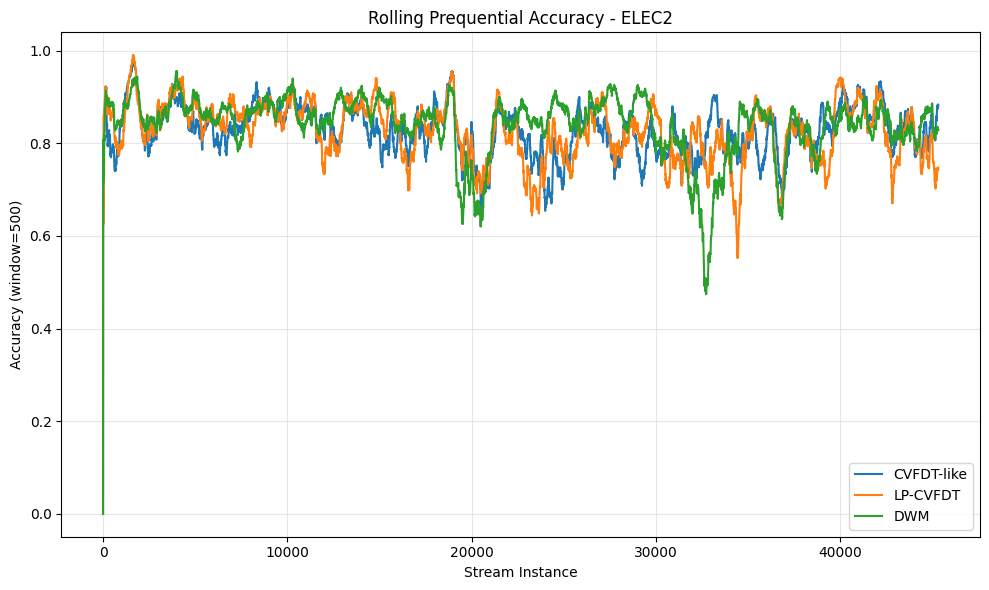

In [15]:
plt.figure(figsize=(10, 6))
for model_name in elec_rolling_df["model"].unique():
    temp = elec_rolling_df[elec_rolling_df["model"] == model_name]
    plt.plot(temp["step"], temp["rolling_accuracy"], label=model_name)

plt.title("Rolling Prequential Accuracy - ELEC2")
plt.xlabel("Stream Instance")
plt.ylabel(f"Accuracy (window={ELEC_ROLLING_WINDOW})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ELEC_RESULTS_DIR, "elec2_rolling_accuracy.png"), dpi=300)
plt.show()

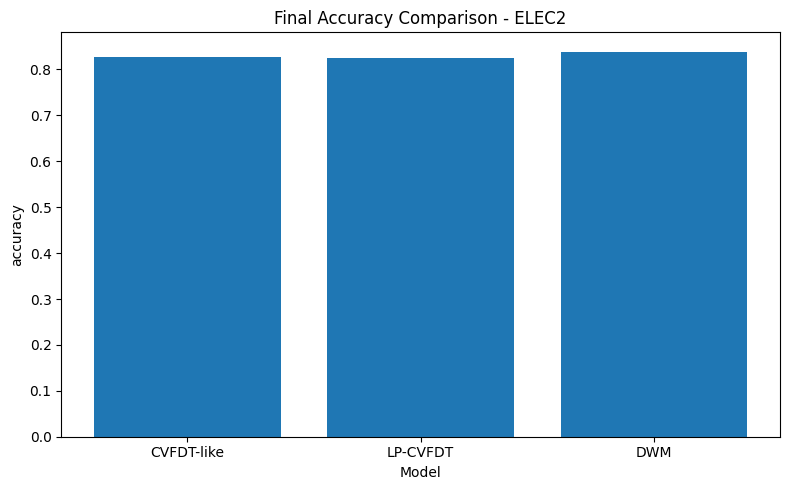

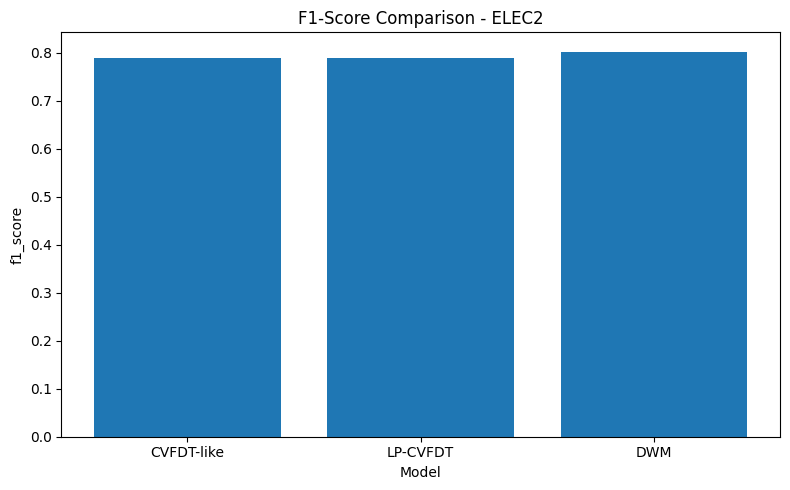

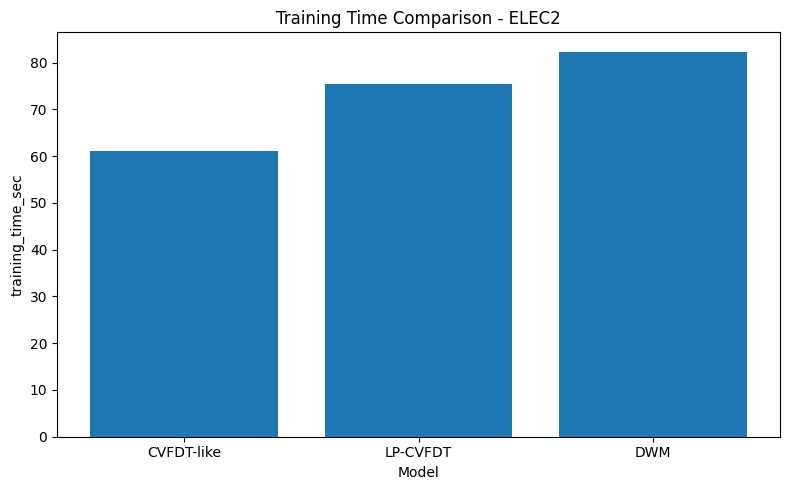

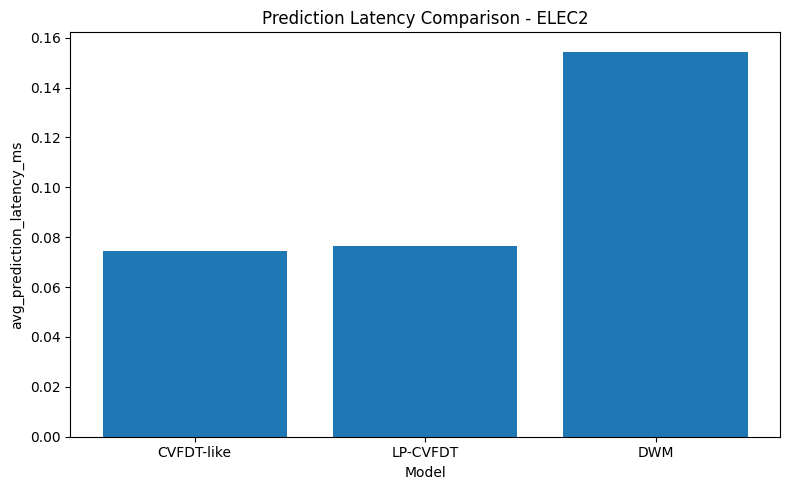

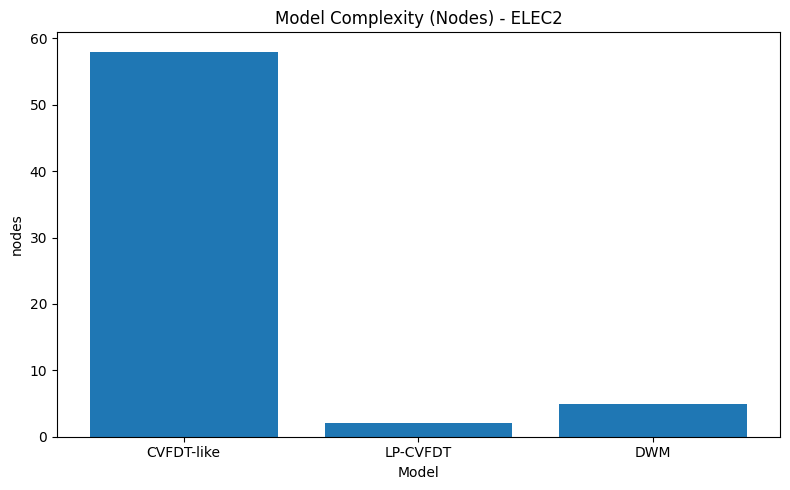

In [16]:
metrics_to_plot = [
    ("accuracy", "Final Accuracy Comparison - ELEC2", "elec2_accuracy.png"),
    ("f1_score", "F1-Score Comparison - ELEC2", "elec2_f1.png"),
    ("training_time_sec", "Training Time Comparison - ELEC2", "elec2_time.png"),
    ("avg_prediction_latency_ms", "Prediction Latency Comparison - ELEC2", "elec2_latency.png"),
    ("nodes", "Model Complexity (Nodes) - ELEC2", "elec2_nodes.png")
]

for metric, title, filename in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.bar(elec_results_df["model"], elec_results_df[metric])
    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.savefig(os.path.join(ELEC_RESULTS_DIR, filename), dpi=300)
    plt.show()

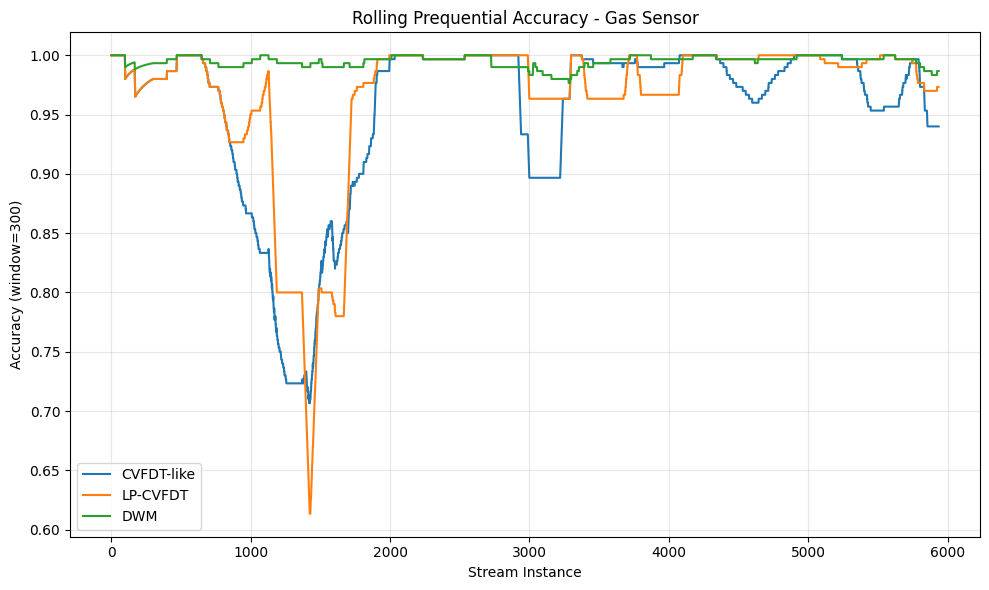

In [17]:
plt.figure(figsize=(10, 6))
for model_name in gas_rolling_df["model"].unique():
    temp = gas_rolling_df[gas_rolling_df["model"] == model_name]
    plt.plot(temp["step"], temp["rolling_accuracy"], label=model_name)

plt.title("Rolling Prequential Accuracy - Gas Sensor")
plt.xlabel("Stream Instance")
plt.ylabel(f"Accuracy (window={GAS_ROLLING_WINDOW})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(GAS_RESULTS_DIR, "gas_rolling_accuracy.png"), dpi=300)
plt.show()

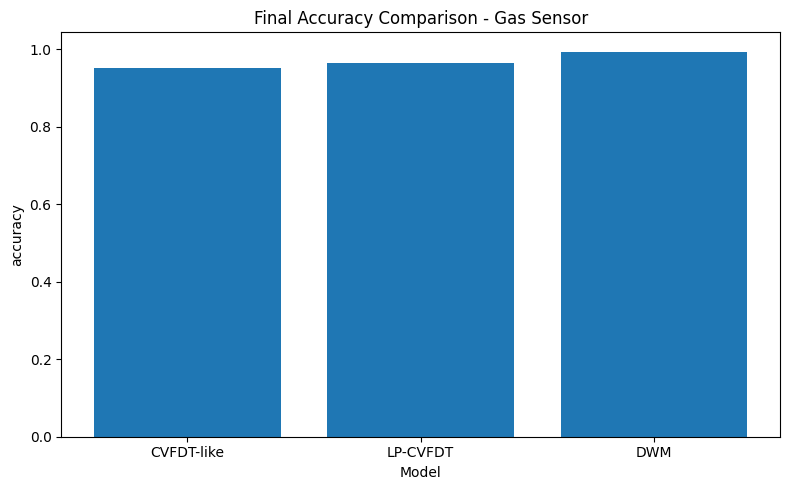

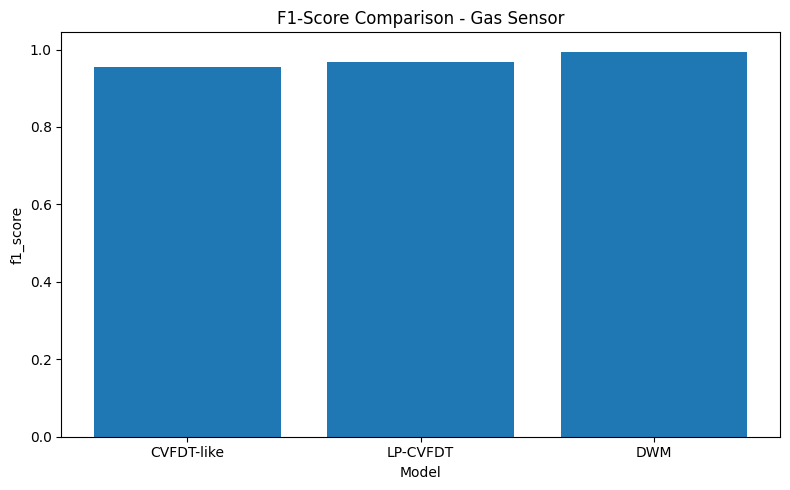

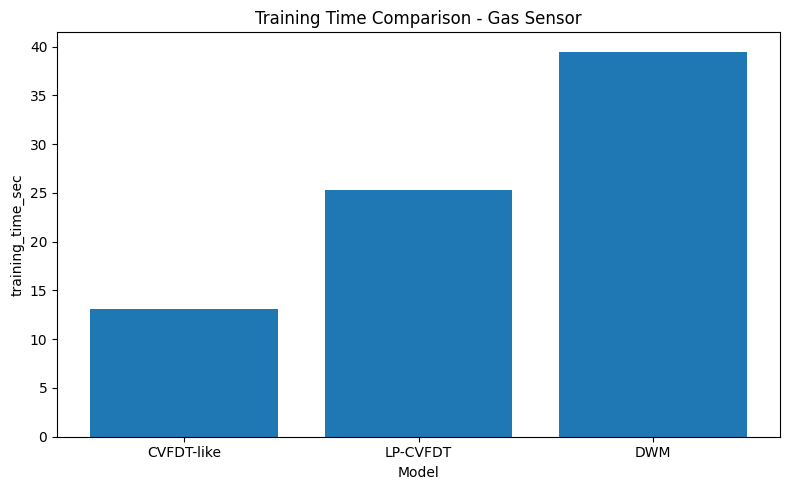

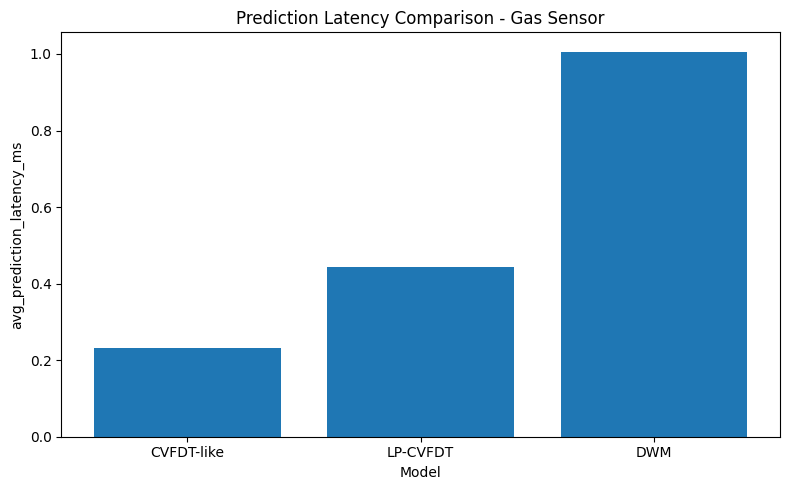

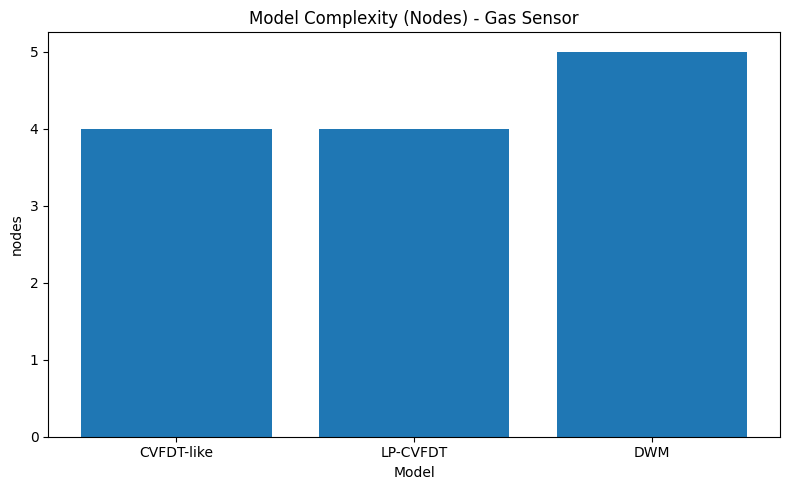

In [18]:
metrics_to_plot = [
    ("accuracy", "Final Accuracy Comparison - Gas Sensor", "gas_accuracy.png"),
    ("f1_score", "F1-Score Comparison - Gas Sensor", "gas_f1.png"),
    ("training_time_sec", "Training Time Comparison - Gas Sensor", "gas_time.png"),
    ("avg_prediction_latency_ms", "Prediction Latency Comparison - Gas Sensor", "gas_latency.png"),
    ("nodes", "Model Complexity (Nodes) - Gas Sensor", "gas_nodes.png")
]

for metric, title, filename in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.bar(gas_results_df["model"], gas_results_df[metric])
    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.savefig(os.path.join(GAS_RESULTS_DIR, filename), dpi=300)
    plt.show()

In [19]:
combined_results_df = pd.concat([elec_results_df, gas_results_df], ignore_index=True)
combined_results_df.to_csv(os.path.join(COMBINED_RESULTS_DIR, "combined_final_results.csv"), index=False)

print("\n================ COMBINED FINAL RESULTS ================\n")
print(combined_results_df)


================ COMBINED FINAL RESULTS ================

     dataset       model  instances  accuracy  precision  recall  f1_score  \
0      ELEC2  CVFDT-like      45312    0.8283     0.8211  0.7614    0.7901   
1      ELEC2    LP-CVFDT      45312    0.8253     0.8083  0.7713    0.7894   
2      ELEC2         DWM      45312    0.8390     0.8358  0.7724    0.8029   
3  GasSensor  CVFDT-like       5935    0.9535     0.9575  0.9505    0.9540   
4  GasSensor    LP-CVFDT       5935    0.9661     0.9520  0.9827    0.9671   
5  GasSensor         DWM       5935    0.9946     0.9953  0.9940    0.9947   

   error_rate  training_time_sec  avg_prediction_latency_ms  tree_depth  \
0      0.1717            61.1928                   0.074319           1   
1      0.1747            75.4846                   0.076370           1   
2      0.1610            82.3705                   0.154453           1   
3      0.0465            13.0863                   0.231589           1   
4      0.0339      

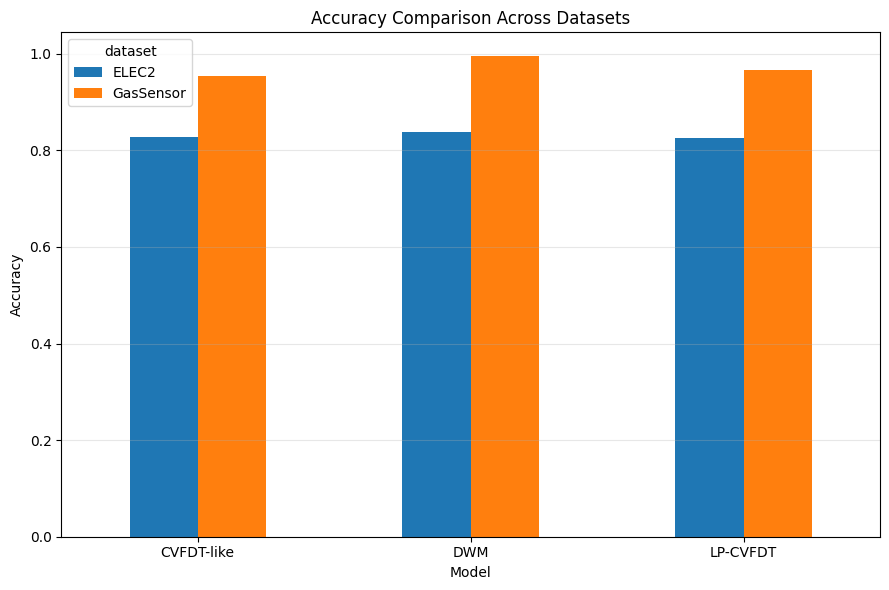

In [20]:
pivot_acc = combined_results_df.pivot(index="model", columns="dataset", values="accuracy")
pivot_acc.plot(kind="bar", figsize=(9, 6))

plt.title("Accuracy Comparison Across Datasets")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(COMBINED_RESULTS_DIR, "combined_accuracy_comparison.png"), dpi=300)
plt.show()

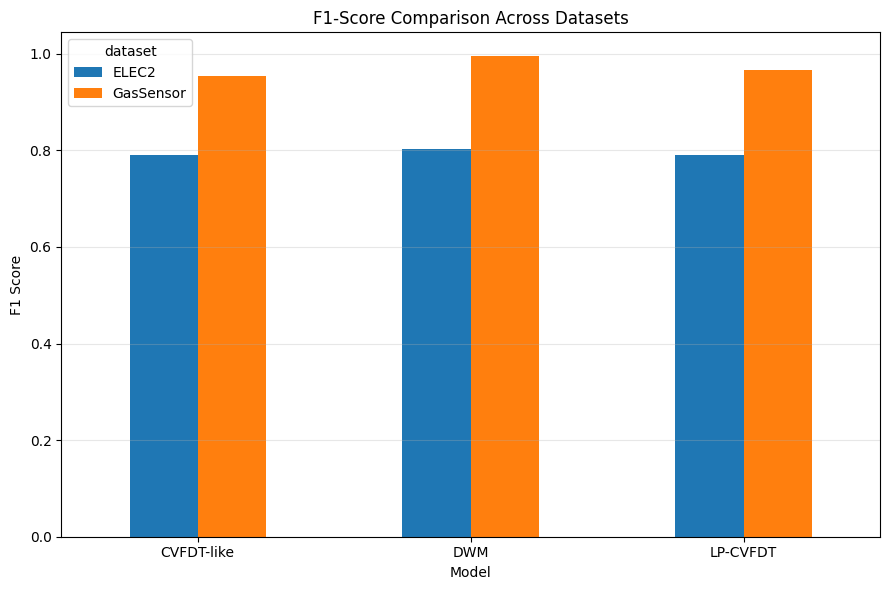

In [21]:
pivot_f1 = combined_results_df.pivot(index="model", columns="dataset", values="f1_score")
pivot_f1.plot(kind="bar", figsize=(9, 6))

plt.title("F1-Score Comparison Across Datasets")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(COMBINED_RESULTS_DIR, "combined_f1_comparison.png"), dpi=300)
plt.show()

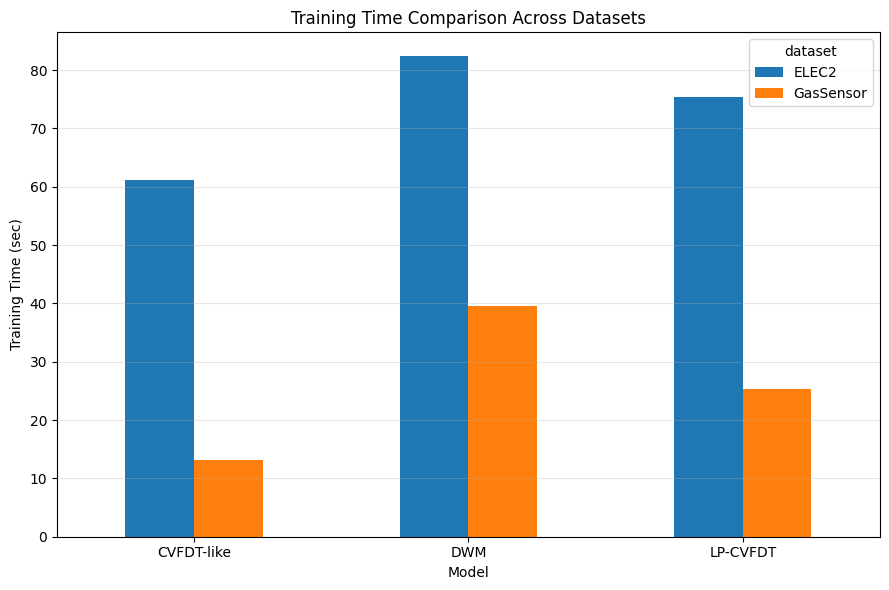

In [22]:
pivot_time = combined_results_df.pivot(index="model", columns="dataset", values="training_time_sec")
pivot_time.plot(kind="bar", figsize=(9, 6))

plt.title("Training Time Comparison Across Datasets")
plt.xlabel("Model")
plt.ylabel("Training Time (sec)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(COMBINED_RESULTS_DIR, "combined_time_comparison.png"), dpi=300)
plt.show()

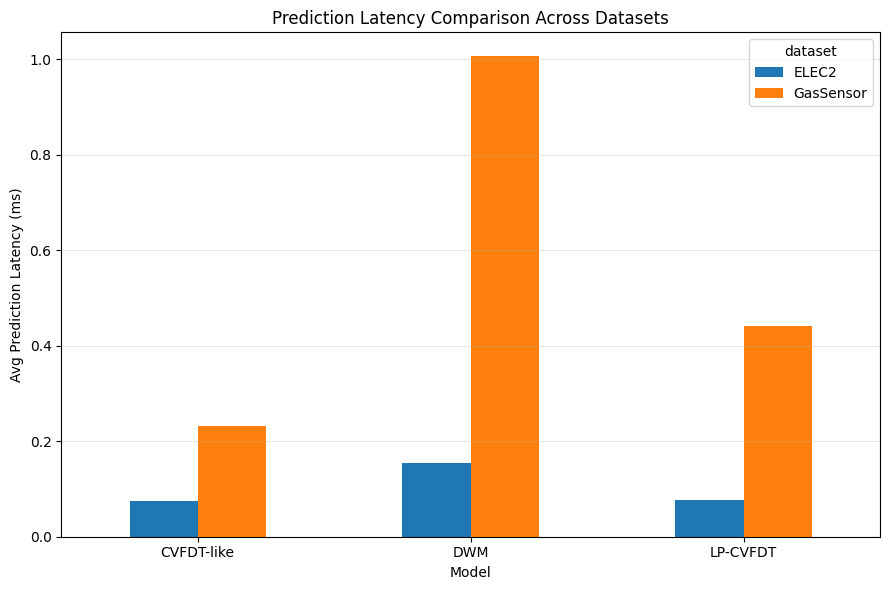

In [23]:
pivot_latency = combined_results_df.pivot(index="model", columns="dataset", values="avg_prediction_latency_ms")
pivot_latency.plot(kind="bar", figsize=(9, 6))

plt.title("Prediction Latency Comparison Across Datasets")
plt.xlabel("Model")
plt.ylabel("Avg Prediction Latency (ms)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(COMBINED_RESULTS_DIR, "combined_latency_comparison.png"), dpi=300)
plt.show()

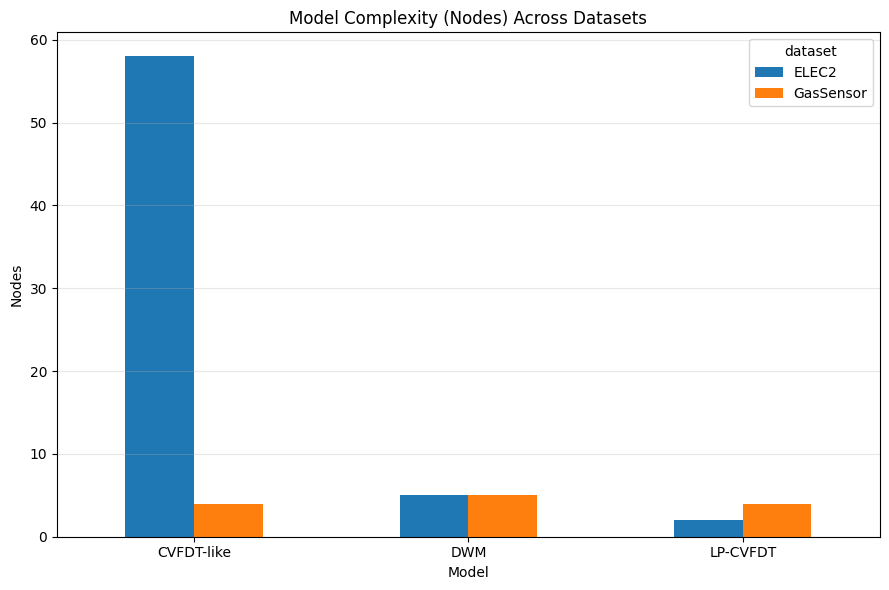

In [24]:
pivot_nodes = combined_results_df.pivot(index="model", columns="dataset", values="nodes")
pivot_nodes.plot(kind="bar", figsize=(9, 6))

plt.title("Model Complexity (Nodes) Across Datasets")
plt.xlabel("Model")
plt.ylabel("Nodes")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(COMBINED_RESULTS_DIR, "combined_nodes_comparison.png"), dpi=300)
plt.show()

In [25]:
print("ELEC2 outputs saved in:", ELEC_RESULTS_DIR)
print("Gas outputs saved in:", GAS_RESULTS_DIR)
print("Combined outputs saved in:", COMBINED_RESULTS_DIR)

ELEC2 outputs saved in: /content/elec2_hd_results
Gas outputs saved in: /content/gas_hd_results
Combined outputs saved in: /content/final_combined_results
